(array([1.011e+03, 5.380e+02, 2.590e+02, 1.200e+02, 5.300e+01, 3.900e+01,
        1.900e+01, 5.000e+00, 1.000e+00, 3.000e+00]),
 array([-1.03521287, -0.30535376,  0.42450535,  1.15436447,  1.88422358,
         2.61408281,  3.34394169,  4.07380056,  4.80365992,  5.53351927,
         6.26337814]),
 <BarContainer object of 10 artists>)

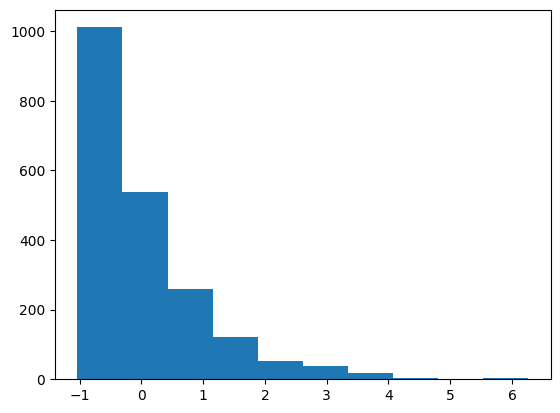

In [67]:
from matplotlib import pyplot as plt
import torch
true_dist = torch.distributions.Exponential(2)

x = true_dist.sample((2048,1))

x-=x.mean()
x/=x.std()

plt.hist(x)

In [68]:
from kemsekov_torch.flow_matching import FlowModel1d
m = FlowModel1d(1)
with torch.no_grad():
    print(m.log_prob(x).mean())
m.fit(x,epochs=128)
with torch.no_grad():
    print(m.log_prob(x).mean())
m.time_scaler

tensor(-1.3939)
tensor(-1.0388)


Parameter containing:
tensor([15.3658], requires_grad=True)

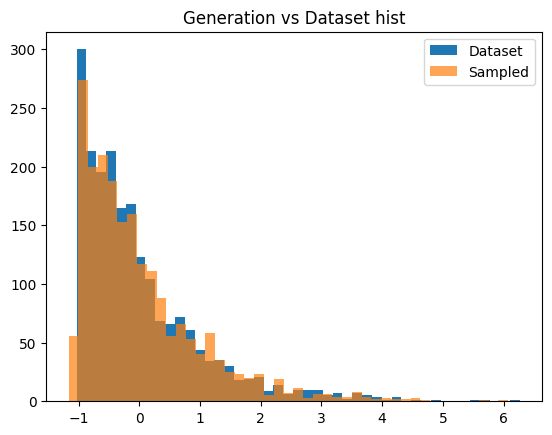

In [72]:
with torch.no_grad():
    sample_x = m.sample(len(x))
bins = int(len(x)**0.5)
plt.hist(x,bins=bins,label='Dataset')
plt.hist(sample_x,alpha=0.7,bins=bins,label='Sampled')
plt.title("Generation vs Dataset hist")
plt.legend()

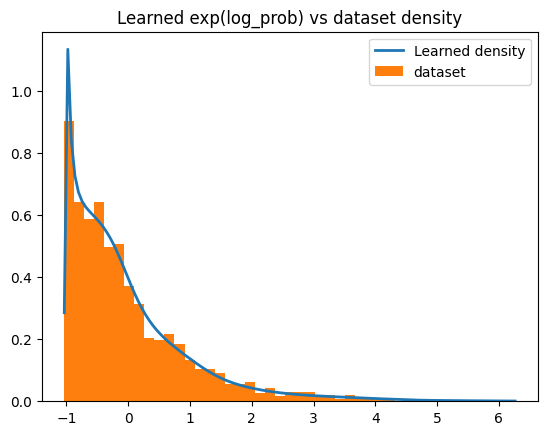

In [114]:
t = torch.linspace(x.min(),x.max(),128)[:,None]
with torch.no_grad():
    logp = m.log_prob(t).exp()
plt.plot(t,logp,label='Learned density',linewidth=2)
plt.hist(x,density=True,bins=bins,label='dataset')
plt.legend()
plt.title("Learned exp(log_prob) vs dataset density")
plt.show()